In [ ]:
import os
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from graph_utils import LJInteractionParams, prepare_traj
from itpo_weights import DatasetType
from utils import calc_p_ratio_box, load_and_split_dataset


In [2]:
registry_data = []

for data_type in ("lj_noisy", ):
# for data_type in ("node_optimized", "stiff_optimized"):
# for data_type in ("stiff_with_angles", ):
    data_path = os.path.join("./data", "data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122")
    for i, sim_chunk in tqdm(enumerate(os.listdir(data_path))):
        chunk_path = os.path.join(data_path, sim_chunk)
        chunk = torch.load(chunk_path, weights_only=False)
        p_ratio = calc_p_ratio_box(chunk)

        registry_data.append(
            {
                "sim_id": i,
                "poisson_ratio": round(p_ratio, 4),
                "data_type": data_type,
                "file_path": chunk_path,
            }
        )
df = pd.DataFrame(registry_data)
# df.to_csv("./data_reid_with_angles/data_registry.csv", index=False)
df.to_csv("./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv", index=False)
df

1348it [02:24,  9.35it/s]


,sim_id,poisson_ratio,data_type,file_path
0,0,0.4238,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
1,1,0.2552,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
2,2,0.5039,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
3,3,0.6125,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
4,4,0.3549,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
...,...,...,...,...
1343,1343,0.3417,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
1344,1344,0.2604,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
1345,1345,0.3252,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....
1346,1346,0.5440,lj_noisy,./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1....


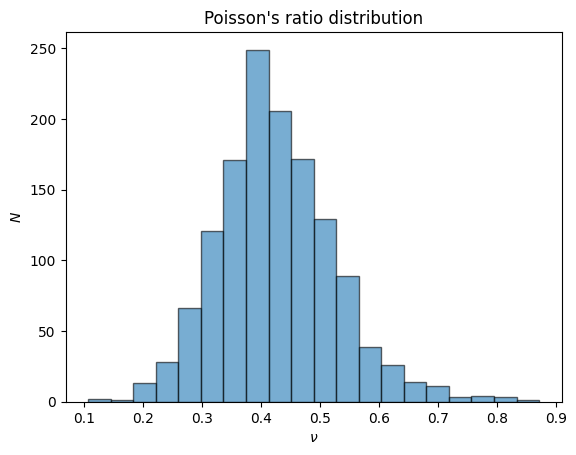

In [3]:
plt.hist(df["poisson_ratio"], bins=20, edgecolor="black", alpha=0.6)
plt.title("Poisson's ratio distribution")
plt.ylabel(r"$N$")
plt.xlabel(r"$\nu$")
plt.show()

In [2]:
my_buckets = [
    {"max": 0.1, "count": 300},  # P < 0.1
    {"min": 0.1, "max": 0.2, "count": 200},  # 0.1 <= P < 0.2
    {"min": 0.2, "count": 200},  # P >= 0.2
]

# Execute the loader
train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    registry_path="./data_reid_with_angles/data_registry.csv",
    target_data_type="stiff_with_angles",
    possion_buckets=my_buckets,
    split_ratios=(0.5, 0.25, 0.25),
    seed=42,
)

print(f"Total Train files: {len(train_files)}")
print(f"Total Val files:   {len(val_files)}")
print(f"Total Test files:  {len(test_files)}")

Total Train files: 243
Total Val files:   121
Total Test files:  123


## Create a small dataset and its own csv

In [ ]:
def create_mini_dataset(
    source_csv: str,
    dest_csv: str,
    dest_dir: str,
    target_samples_per_type: int = 300,
    n_bins: int = 15,
    random_seed: int = 42,
):
    """
    Creates a flat Poisson distribution subset, maintaining data_type subdirectories.
    """
    print(f"Loading original registry from {source_csv}...")
    df = pd.read_csv(source_csv)

    os.makedirs(dest_dir, exist_ok=True)

    subset_dfs = []
    samples_per_bin = target_samples_per_type // n_bins

    # 1. Stratified Sampling (Identical to before)
    for data_type, type_df in df.groupby("data_type"):
        print(f"\nProcessing '{data_type}'...")

        p_min, p_max = type_df["poisson_ratio"].min(), type_df["poisson_ratio"].max()
        bins = np.linspace(p_min, p_max, n_bins + 1)

        type_df = type_df.copy()
        type_df["bin"] = pd.cut(
            type_df["poisson_ratio"], bins=bins, include_lowest=True
        )

        sampled_rows = []
        for bin_name, bin_df in type_df.groupby("bin", observed=False):
            available = len(bin_df)
            if available == 0:
                continue

            take_n = min(available, samples_per_bin)
            sampled = bin_df.sample(n=take_n, random_state=random_seed)
            sampled_rows.append(sampled)

            if available < samples_per_bin:
                print(f"  - Bin {bin_name}: Warning, only found {available} samples (wanted {samples_per_bin}).")

        sampled_type_df = pd.concat(sampled_rows)
        print(f"  -> Extracted {len(sampled_type_df)} samples for '{data_type}'.")
        subset_dfs.append(sampled_type_df)

    final_mini_df = pd.concat(subset_dfs).reset_index(drop=True)
    final_mini_df = final_mini_df.drop(columns=["bin"])

    print(f"\nCopying {len(final_mini_df)} files to {dest_dir}...")

    # We define what the "old" base directory was in the CSV (e.g., "./data")
    old_base_dir = "./data"

    for idx, row in final_mini_df.iterrows():
        src_path = row["file_path"]  # e.g., "./data/NPT/sim_001.pt"

        # 1. Strip the old base directory to get the pure folder structure
        # This turns "./data/NPT/sim_001.pt" into "NPT/sim_001.pt"
        rel_structure = os.path.relpath(src_path, start=old_base_dir)

        # 2. Build the new destination path
        # This turns "NPT/sim_001.pt" into "./data_mini/NPT/sim_001.pt"
        dst_path = os.path.join(dest_dir, rel_structure)

        # 3. Dynamically create whatever subdirectories are needed
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)

        # 4. Copy the file safely
        if os.path.exists(src_path):
            shutil.copy2(src_path, dst_path)
        else:
            print(f"  ERROR: Source file missing -> {src_path}")

        if (idx + 1) % 100 == 0:
            print(f"  Copied {idx + 1}/{len(final_mini_df)} files...")

    # 5. Update the CSV file paths to point to the new mini folder
    final_mini_df["file_path"] = final_mini_df["file_path"].apply(
        lambda path: os.path.join(dest_dir, os.path.relpath(path, start=old_base_dir))
    )

    final_mini_df.to_csv(dest_csv, index=False)
    print(f"\nDone! Mini dataset saved to {dest_dir} and registry to {dest_csv}.")

    # 3. Update the CSV file paths to reflect the subdirectories (optional but recommended)
    # This ensures the mini CSV is perfectly plug-and-play for the user
    final_mini_df["file_path"] = final_mini_df.apply(
        lambda r: f"{r['data_type']}/{os.path.basename(r['file_path'])}", axis=1
    )

    final_mini_df.to_csv(dest_csv, index=False)
    print(f"\nDone! Mini dataset saved to {dest_dir} and registry to {dest_csv}.")


create_mini_dataset(
    source_csv="./data/data_registry.csv",  
    dest_csv="data_mini/data_registry_mini.csv",  
    dest_dir="data_mini",  
    target_samples_per_type=400,  
    n_bins=15,
)

In [ ]:

mini_df = pd.read_csv("./data_mini/data_registry_mini.csv")

for data_type, type_df in mini_df.groupby("data_type"):
    plt.hist(
        type_df["poisson_ratio"],
        bins=15,
        edgecolor="black",
        alpha=0.7,
        label=f"{data_type}",
    )

plt.legend()
plt.show()

## Load any dataset

In [ ]:
poisson_buckets = [
    {"min": 0.0, "max": 1.0, "count": 100},    # 0.1 <= P < 0.2
]

dataset_type = DatasetType.LJNoisy

train_files, val_files, test_files = load_and_split_dataset(
    # registry_path="./data_mini/data_registry_mini.csv",
    # registry_path="./data_reid_with_angles/data_registry.csv",
    registry_path="./data/data_LJ_noisy_eps0.01_sigma1.0_cutoff1.122/data_registry.csv",
    target_data_type=dataset_type,
    possion_buckets=poisson_buckets,
    split_ratios=(0.9, 0.05, 0.05),
    seed=42
)

# Load actual data
data = {
    'train': {},
    'val' : {},
    'test' : {},
}
print("Loading data...")
for key in data:
    if key == 'train':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(train_files, desc=f"{key:<5} data")]
    elif key == 'val':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(val_files, desc=f"{key:<5} data")]
    elif key == 'test':
        data[key] = [torch.load(file, weights_only=False) for file in tqdm(test_files, desc=f"{key:<5} data")]
    else:
        raise ValueError(f"Unexpected key in data dictionary: {key}. ")

print("\nPreparing data...")
for data_type, sims in data.items():
    prepared = []
    for sim in tqdm(sims, desc=f"{data_type:<5} data"):
        lj_params = LJInteractionParams(0.01, 1.0, 1.112)
        prepared_sim = prepare_traj(sim, lj_params, calc_angles=False)
        prepared.append(prepared_sim)
    data[data_type] = prepared

print(f"\nTrain data: {len(data['train'])} sims.")
print(f"Val data:   {len(data['val'])} sims.")
print(f"Test data:  {len(data['test'])} sims.")


Loading data...


test  data: 100%|██████████| 5/5 [00:00<00:00, 11.41it/s]



Preparing data...


test  data: 100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


Train data: 90 sims.
Val data:   5 sims.
Test data:  5 sims.


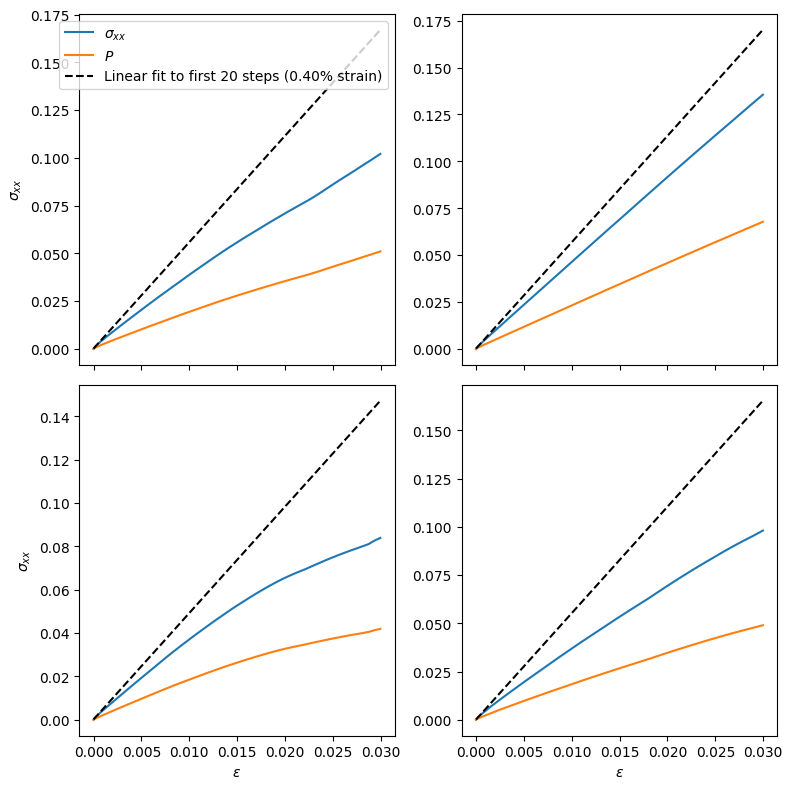

In [13]:
from pressure import compute_stress_curve

n_sims = 4
random_sims = random.sample(data["train"], k=n_sims)
strain = [(random_sims[0][0].box_tensor[0] - g.box_tensor[0])/random_sims[0][0].box_tensor[0] for g in random_sims[0]]

fig, ax = plt.subplots(2, 2, layout="tight", figsize=(8, 8), sharex=True)

for i, (random_sim, ax_current) in enumerate(zip(random_sims, ax.flatten())):

    # Compute stress and pressure
    stress_curve = compute_stress_curve(random_sim, sample_stride=1)
    stress_xx = stress_curve[:, 0]
    stress_yy = stress_curve[:, 1]
    pressure = torch.abs(stress_xx + stress_yy) / 2

    # Linear fit to the beginning
    steps_to_fit = 20
    x_fit = strain[:steps_to_fit]
    y_fit = stress_xx[:steps_to_fit]

    a, b = np.polyfit(x_fit, y_fit, deg=1)
    line = [a*s + b for s in strain]

    ax_current.plot(strain, stress_xx, label=r"$\sigma_{xx}$")
    # ax_current.plot(strain, stress_yy, label=r"$\sigma_{yy}$")
    ax_current.plot(strain, pressure, label="$P$")
    ax_current.plot(strain, line, linestyle="--", color="black", label=f"Linear fit to first {steps_to_fit} steps ({20 / 1000 * steps_to_fit:.2f}% strain)")
    if i == 0:
        ax_current.legend()
    if i == 0 or i == 2:
        ax_current.set_ylabel(r'$\sigma_{xx}$')
    if i == 2 or i == 3:
        ax_current.set_xlabel(r'$\epsilon$')

plt.show()

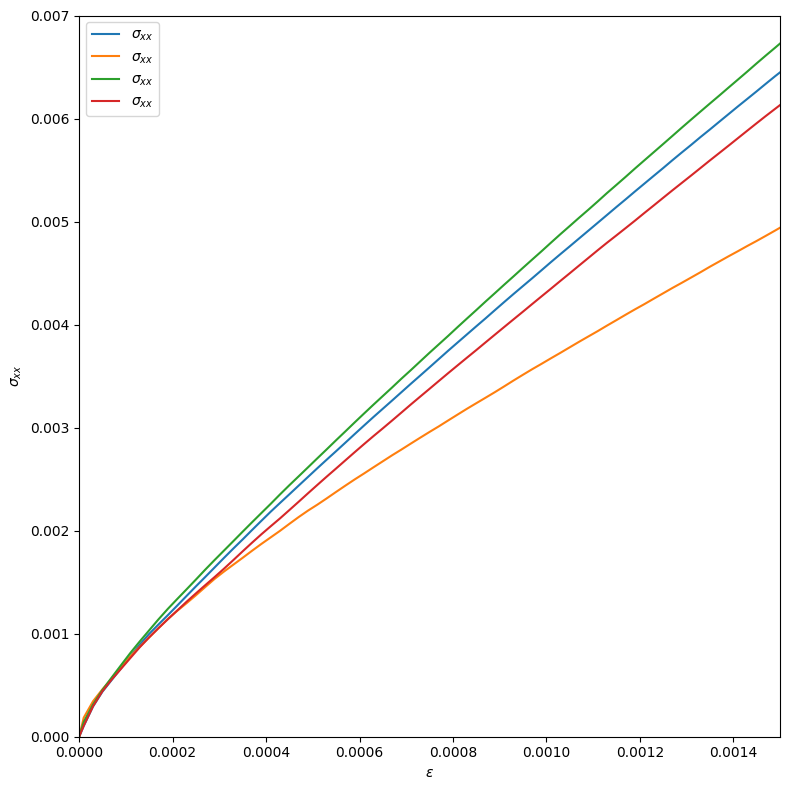

In [25]:
from pressure import compute_stress_curve

n_sims = 4
random_sims = random.sample(data["train"], k=n_sims)
strain = [(random_sims[0][0].box_tensor[0] - g.box_tensor[0])/random_sims[0][0].box_tensor[0] for g in random_sims[0]]

fig, ax = plt.subplots(1, 1, layout="tight", figsize=(8, 8), sharex=True)

for i, random_sim in enumerate(random_sims):

    # Compute stress and pressure
    stress_curve = compute_stress_curve(random_sim, sample_stride=1)
    stress_xx = stress_curve[:, 0]
    stress_yy = stress_curve[:, 1]
    pressure = torch.abs(stress_xx + stress_yy) / 2

    # Linear fit to the beginning
    steps_to_fit = 20
    x_fit = strain[:steps_to_fit]
    y_fit = stress_xx[:steps_to_fit]

    a, b = np.polyfit(x_fit, y_fit, deg=1)
    line = [a*s + b for s in strain]

    ax.plot(strain, stress_xx, label=r"$\sigma_{xx}$")
    # ax_current.plot(strain, stress_yy, label=r"$\sigma_{yy}$")
    # ax.plot(strain, pressure, label="$P$")
    # ax.plot(strain, line, linestyle="--", color="black", label=f"Linear fit to first {steps_to_fit} steps ({20 / 1000 * steps_to_fit:.2f}% strain)")
    # if i == 0:
    ax.legend()
    ax.set_ylabel(r'$\sigma_{xx}$')
    ax.set_xlabel(r'$\epsilon$')
    ax.set_ylim(0, 0.007)
    ax.set_xlim(0, 0.0015)

plt.show()

### Load registry to check data

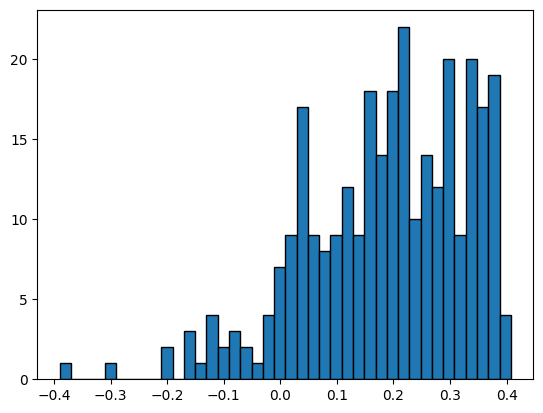

In [7]:
df = pd.read_csv("data/new_node_optimized/data_registry.csv")
plt.hist(df['poisson_ratio'], bins=40, edgecolor="black")
plt.show()